## Rossmann Store Sales Analytics: Understanding Store Performance, Promotions, Customers and Sales Trends

### Project Overview
Rossmann operates over 3,000 drug stores in 7 European countries. In this project, we are analyzing historical sales data to understand the factors that influence store performance.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [15]:
store = pd.read_csv('/home/r0b0t/Videos/KeDataLab/Python For Data Analytics/Week 3/Week 5/Rossman Sales Analysis/Data/store.csv')
train = pd.read_csv('/home/r0b0t/Videos/KeDataLab/Python For Data Analytics/Week 3/Week 5/Rossman Sales Analysis/Data/train.csv', low_memory=False)

In [16]:
# preview our data
summary_df = pd.DataFrame({
    'Dataset': ['store.csv', 'train.csv'],
    'Rows': [len(train), len(store)],
    'Columns': [len(train.columns), len(store.columns)]
})

display(summary_df)
display(train.head())
display(store.head())

,Dataset,Rows,Columns
0,store.csv,1017209,9
1,train.csv,1115,10


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [17]:
# data quality audit
def quality_audit(df, name):
    print(f'--- Data Quality Audit for {name}')

    audit = pd.DataFrame({
        'Missing Values': df.isnull().sum(),
        'Missing %': (df.isnull().sum()/len(df))*100,
        'Data Types': df.dtypes,
        'Unique Values': df.nunique()
    })
    display(audit[audit['Missing Values'] >0].sort_values(by='Missing Values', ascending=False))
    print(f"Duplicate Rows: {df.duplicated().sum()}")

quality_audit(store, 'Store Data')
quality_audit(train, 'Train Data')

--- Data Quality Audit for Store Data


,Missing Values,Missing %,Data Types,Unique Values
Promo2SinceYear,544,48.789238,float64,7
Promo2SinceWeek,544,48.789238,float64,24
PromoInterval,544,48.789238,str,3
CompetitionOpenSinceMonth,354,31.748879,float64,12
CompetitionOpenSinceYear,354,31.748879,float64,23
CompetitionDistance,3,0.269058,float64,654


Duplicate Rows: 0
--- Data Quality Audit for Train Data


,Missing Values,Missing %,Data Types,Unique Values


Duplicate Rows: 0


### Data Cleaning

In [18]:
# convert date to datetime
train['Date'] = pd.to_datetime(train['Date'])

In [19]:
# Handle missing CompetitionDistance (Fill with median competition distance)
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(store['CompetitionDistance'].median())

In [20]:
# Handle promo missing values
promo2_cols = ['Promo2SinceYear', 'Promo2SinceWeek', 'PromoInterval']

for col in promo2_cols:
    store[col] = store[col].fillna(0)

In [21]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


In [22]:
# handle missing competition open dates
store['CompetitionOpenSinceMonth'] = store['CompetitionOpenSinceMonth'].fillna(0)
store['CompetitionOpenSinceYear'] = store['CompetitionOpenSinceYear'].fillna(0)

#### Merging Data and Analytical Grain

In [23]:
# record rows before merge
len(train)

1017209

In [24]:
# how do we merge? train is our main table so we can do left join
df = train.merge(store, on='Store', how='left')
# on is the column we use to merge.. the column shared

In [25]:
# see the rows after merge
len(df)

1017209

In [26]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


In [27]:
# check if there are unmatched stores
print(f'Unmatched stores: {df['StoreType'].isnull().sum()}')

Unmatched stores: 0


### Feature Engineering
process of creating new features from existing/raw data or transforming existing features into new ones. 
So we now want to create a few data elements to use in our analysis

In [28]:
# Time hierachy features
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.month_name()
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day
df['DayOfWeek_Name'] = df['Date'].dt.day_name()

In [29]:
# Business date features
df['is_weekend'] = df['DayOfWeek'].isin([6,7]).astype(int)
df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)

In [30]:
df['is_month_end'].unique()

array([1, 0])

#### Promo, Customer, Store, & Competition Features

Customer features

In [31]:
# 1. sales per customer (avoid division by zero error due to customer data being absent or 0)
df['Sales Per Customer'] = np.where(df['Customers']>0, df['Sales']/df['Customers'], 0)
#.where is a numpy function that performs a calculation when the condition is met. if condition is
# met, do the 2nd argument in the function. if not met, do the 3rd argument (fill with 0 in this case)


In [32]:
# store performance summary
store_summary = df[df['Open'] == 1].groupby('Store').agg(
    Total_Sales = ('Sales', 'sum'),
    Avg_Daily_Sales = ('Sales', 'mean'),
    Total_Customers = ('Customers', 'sum'),
    Avg_Sales_Per_Customer = ('Customers', 'mean'),
    Promo_Rate = ('Promo', 'mean')
).reset_index()

In [33]:
store_summary.head()

,Store,Total_Sales,Avg_Daily_Sales,Total_Customers,Avg_Sales_Per_Customer,Promo_Rate
0,1,3716854,4759.096031,440523,564.049936,0.448143
1,2,3883858,4953.900510,457855,583.998724,0.451531
2,3,5408261,6942.568678,584310,750.077022,0.449294
3,4,7556507,9638.401786,1036254,1321.752551,0.450255
4,5,3642818,4676.274711,418588,537.340180,0.450578


In [34]:
# Rank stores by total sales
store_summary['Rank'] = store_summary['Total_Sales'].rank(ascending=False)
#what value does rank produce?

In [35]:
store_summary.head()

,Store,Total_Sales,Avg_Daily_Sales,Total_Customers,Avg_Sales_Per_Customer,Promo_Rate,Rank
0,1,3716854,4759.096031,440523,564.049936,0.448143,900.0
1,2,3883858,4953.900510,457855,583.998724,0.451531,854.0
2,3,5408261,6942.568678,584310,750.077022,0.449294,449.0
3,4,7556507,9638.401786,1036254,1321.752551,0.450255,101.0
4,5,3642818,4676.274711,418588,537.340180,0.450578,923.0


### Advanced Time Series and Sales Change Features

#### We want to calculate the 7-day rolling average which is taking sum of sales for the past 6 days and dividing by 7

In [36]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Quarter,Month,MonthName,WeekOfYear,Day,DayOfWeek_Name,is_weekend,is_month_start,is_month_end,Sales Per Customer
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,3,7,July,31,31,Friday,0,0,1,9.482883
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,3,7,July,31,31,Friday,0,0,1,9.702400
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,3,7,July,31,31,Friday,0,0,1,10.126675
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,3,7,July,31,31,Friday,0,0,1,9.342457
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,3,7,July,31,31,Friday,0,0,1,8.626118


In [37]:
# sort by store and date for proper calculations of sales in continous dates
df = df.sort_values(by=['Store', 'Date'])

In [38]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Quarter,Month,MonthName,WeekOfYear,Day,DayOfWeek_Name,is_weekend,is_month_start,is_month_end,Sales Per Customer
1016095,1,2,2013-01-01,0,0,0,0,a,1,c,...,1,1,January,1,1,Tuesday,0,1,0,0.000000
1014980,1,3,2013-01-02,5530,668,1,0,0,1,c,...,1,1,January,1,2,Wednesday,0,0,0,8.278443
1013865,1,4,2013-01-03,4327,578,1,0,0,1,c,...,1,1,January,1,3,Thursday,0,0,0,7.486159
1012750,1,5,2013-01-04,4486,619,1,0,0,1,c,...,1,1,January,1,4,Friday,0,0,0,7.247173
1011635,1,6,2013-01-05,4997,635,1,0,0,1,c,...,1,1,January,1,5,Saturday,1,0,0,7.869291


In [39]:
# calculate 7-day rolling average sales per store
df['7d_Rolling_Sales_Average'] = df.groupby('Store')['Sales'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

In [40]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Month,MonthName,WeekOfYear,Day,DayOfWeek_Name,is_weekend,is_month_start,is_month_end,Sales Per Customer,7d_Rolling_Sales_Average
1016095,1,2,2013-01-01,0,0,0,0,a,1,c,...,1,January,1,1,Tuesday,0,1,0,0.000000,0.000000
1014980,1,3,2013-01-02,5530,668,1,0,0,1,c,...,1,January,1,2,Wednesday,0,0,0,8.278443,2765.000000
1013865,1,4,2013-01-03,4327,578,1,0,0,1,c,...,1,January,1,3,Thursday,0,0,0,7.486159,3285.666667
1012750,1,5,2013-01-04,4486,619,1,0,0,1,c,...,1,January,1,4,Friday,0,0,0,7.247173,3585.750000
1011635,1,6,2013-01-05,4997,635,1,0,0,1,c,...,1,January,1,5,Saturday,1,0,0,7.869291,3868.000000


In [41]:
# calculate day-over-day percentage change (only for open stores to avoid artificial 100% drops)
df_open = df[df['Open'] == 1].copy()
df_open['Daily_Sales_Pct_Change'] = df_open.groupby('Store')['Sales'].pct_change()

In [42]:
df_open.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,MonthName,WeekOfYear,Day,DayOfWeek_Name,is_weekend,is_month_start,is_month_end,Sales Per Customer,7d_Rolling_Sales_Average,Daily_Sales_Pct_Change
1014980,1,3,2013-01-02,5530,668,1,0,0,1,c,...,January,1,2,Wednesday,0,0,0,8.278443,2765.000000,NaN
1013865,1,4,2013-01-03,4327,578,1,0,0,1,c,...,January,1,3,Thursday,0,0,0,7.486159,3285.666667,-0.217541
1012750,1,5,2013-01-04,4486,619,1,0,0,1,c,...,January,1,4,Friday,0,0,0,7.247173,3585.750000,0.036746
1011635,1,6,2013-01-05,4997,635,1,0,0,1,c,...,January,1,5,Saturday,1,0,0,7.869291,3868.000000,0.113910
1009405,1,1,2013-01-07,7176,785,1,1,0,1,c,...,January,2,7,Monday,0,0,0,9.141401,3788.000000,0.436062


### Exploratory Data Analysis (EDA)

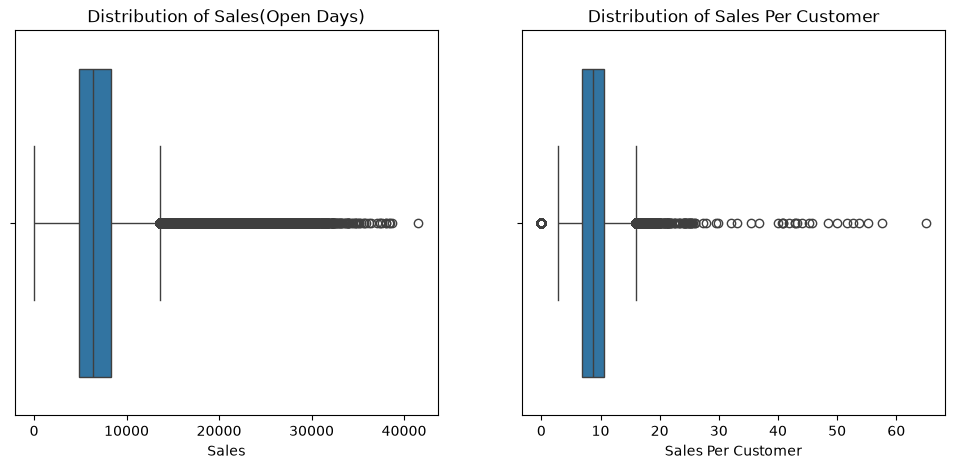

In [43]:
# we will use subplots to analyse the distribution of our data. we need to understand our data
# and know any outliers. sometimes its a wrong entry, other times its real sales that were beyond normal

#Outlier analysis
plt.figure(figsize=(12,5))
plt.subplot(1,2,1) # 1 row, divide rectangle into 2 columns, make 1st box active
sns.boxplot(x=df_open['Sales'])
plt.title('Distribution of Sales(Open Days)')

plt.subplot(1,2,2)
sns.boxplot(x=df['Sales Per Customer'])
plt.title('Distribution of Sales Per Customer')
plt.savefig('outlier_analysis.png')
plt.show()

1. Both overall daily sales and sales per customer exhibit a heavy rightward skew, characterized by a long tail of high-value outliers extending far beyond the upper whiskers.
2. For total daily sales on open days, the central 50% of the data is tightly concentrated, yet the business experiences a massive, dense volume of extreme revenue spikes that can push past 40,000

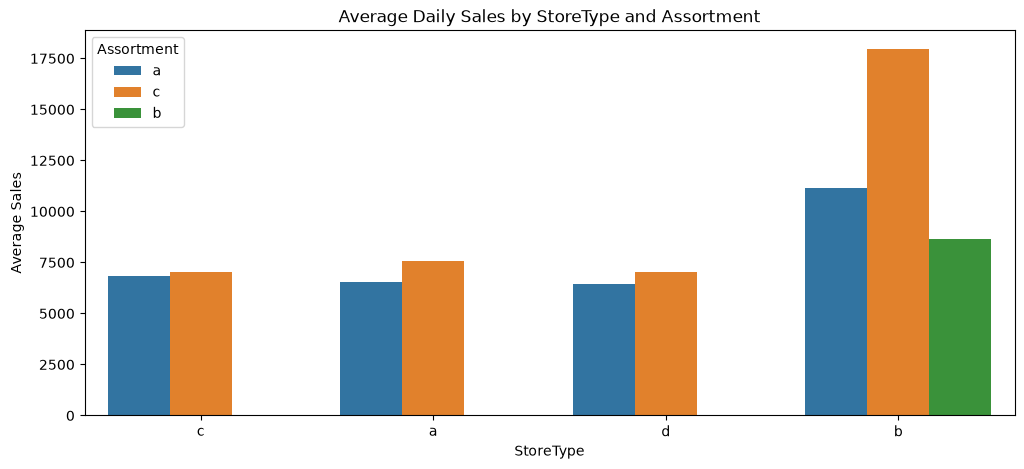

In [44]:
# which storetypes have different sales patterns
plt.figure(figsize=(12,5))
sns.barplot(data=df_open, x='StoreType', y='Sales', hue='Assortment', errorbar=None, estimator=np.mean)
plt.title('Average Daily Sales by StoreType and Assortment')
plt.ylabel('Average Sales')
plt.savefig('storetype.png')
plt.show()

1. Store Type 'b' has a drastically different and significantly higher sales pattern compared to the rest.
2. Store types 'a', 'c' and 'd' perform very similar to one another, with average daily sales hovering between roughly 6,000 and 7,500
3. In contrast, Store Type 'b' generates over 10,000 in average sales for its lowest-performing shared category and nearly 17,500 in its highest.
4. Additionally, Store Type 'b' is the only store type that sells Assortment 'b' (the green bar)

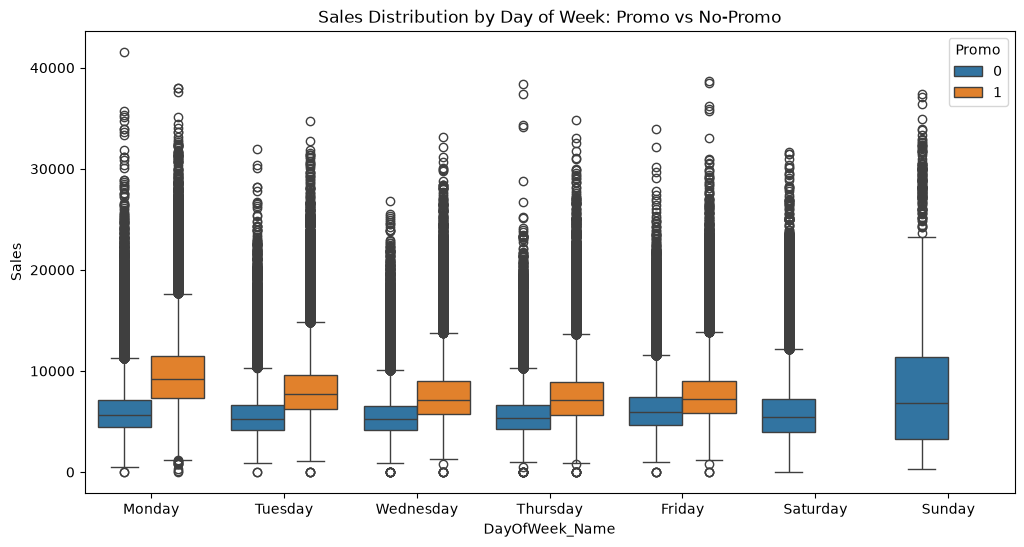

In [45]:
# how do promotions relate to sales across different days of the week?
# that is, how sales perform in promo vs no-promo days
plt.figure(figsize=(12,6))
sns.boxplot(data=df_open, x='DayOfWeek_Name', y='Sales', hue='Promo',
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Sales Distribution by Day of Week: Promo vs No-Promo')
plt.savefig('promo_analysis.png')
plt.show()

1. Promotions consistently drive higher sales volumes across the standard workweek, lifting both the median and the entire interquartile range from Monday through Friday compared to non-promotional days.
2. The business restricts this promotional strategy exclusively to weekdays, evidenced by the complete absence of active promotions (orange boxes) on Saturdays and Sundays.
3. Monday acts as the strongest sales day of the standard workweek, showing the highest median sales for both promotional and non-promotional categories.
4. Non-promotional baseline sales gradually taper off as the week progresses from Monday to Saturday.
5. Sunday displays a highly unique non-promotional sales distribution, featuring a much wider interquartile range and a higher median than any other non-promotional day.
6. every day of the week exhibits a dense concentration of extreme high-value outliers extending far above the upper whiskers, indicating that certain stores or specific calendar events drive massive revenue spikes regardless of the standard weekly rhythm.

#### Interactive Visualization (using Plotly)

In [46]:
# Aggregate monthly sales across all stores for time-series viewing
monthly_sales = df[df['Open']==1].groupby(['Year', 'Month', 'MonthName'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-' +
                                       monthly_sales['Month'].astype(str) + '-01')
fig = px.line(monthly_sales, x='Date', y='Sales', markers=True,
              title='Total Rossman Sales Over Time',
              labels={'Sales': 'Total Sales ($)'})
fig.update_layout(hovermode='x unified')
fig.show()

1. Strong Year-End Seasonality: Total sales exhibit a massive spike at the end of the year, visibly peaking at well over 220 million euros just before January 2014.

2. Mid-Year Sales Dips: There is a recurring trend of lower sales during the summer months, with a particularly sharp trough occurring shortly after July 2014, where sales dropped below 160 million euros.

3. Cyclical Volatility: The time series displays consistent month-to-month volatility, characterized by sharp, regular peaks and valleys that dictate the short-term sales rhythm throughout each year.

4. 2015 Recovery Trend: Following the significant dip in mid-2014, total sales show a distinct recovery trajectory, trending steadiy upward through the 1st half of 2015 and crossing back over the 200 million euro mark just before July 2015.

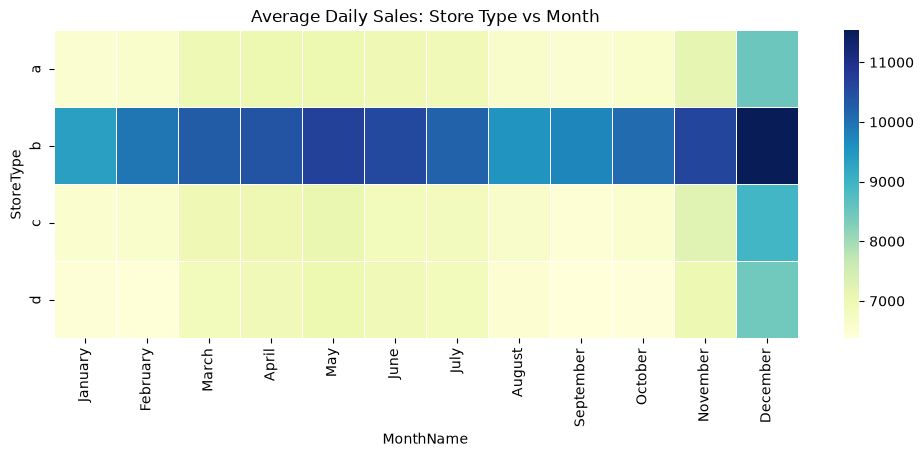

In [49]:
# Groupby and Multi-Level Analysis
# Create a heatmap of sales by month and storetype

heatmap_data = df[df['Open']==1].pivot_table(
    values='Sales',
    index='StoreType',
    columns='MonthName',
    aggfunc='mean'
)[['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October',
   'November', 'December']]

plt.figure(figsize=(12,4))
sns.heatmap(heatmap_data, annot=False, cmap='YlGnBu', linewidths=.5)
plt.title('Average Daily Sales: Store Type vs Month')
plt.savefig('heatmap.png')
plt.show()

1. Universal December Surge: Every single store type experiences a significant spike in average daily sales during December, visible as a distinct vertical band of darker colors on the right edge of the heatmap.

2. Year-Round Dominance of Type 'b': Store Type 'b' consistently outperforms all other store types across every month of the year, maintaining a dark blue presence indicating average daily sales well above 9,000. Its sales peak to the highest recorded level on the chart (darkest blue, exceeding 11,000) during December.

3. Stability Across Standard Models: Store Types 'a', 'c', and 'd' exhibit extremely flat and uniform sales behavior from January through November. Their average daily sales remain tightly clustered in the pale yellow range (Around 6,500 to 7,500) for eleven months of the year before shifting to the teal range in December.

### Recommendations

1. Test Weekend Promotional Campaigns
The data shows a complete absence of active promotions on Saturdays and Sundays, yet promotions are the strongest driver of baseline sales from Monday through Friday. Implementing targeted weekend promotions—especially on Saturday, which already maintains a decent baseline—could capture untethered weekend foot traffic and smooth out the steep drop in revenue observed at the end of the week.

2. Upgrade Store Assortments from 'a' to 'c'
Across all store models ('a', 'c', and 'd'), locations carrying Assortment 'c' consistently generate higher daily sales than those with Assortment 'a'. Management should conduct a spatial and logistical audit of top-performing Assortment 'a' stores to determine if they have the physical capacity to carry the extended 'c' inventory. This is the clearest structural lever for increasing baseline revenue.

3. Study and Replicate the Store Type 'b' Model
Store Type 'b' operates on a completely different revenue scale, dwarfing the performance of standard neighborhood stores across every month of the year. Because these are likely high-traffic transit hubs or flagship hypermarkets, the real estate strategy should prioritize identifying similar high-density commercial zones for future expansion rather than solely saturating suburbs with standard 'a', 'c', or 'd' models.

4. Implement Basket-Size Upselling Tactics
While total daily sales show massive spikes and high volatility, the distribution of sales per customer remains remarkably flat, clustering tightly around 10 euros. This indicates that revenue spikes are driven entirely by foot traffic rather than customers buying more items per visit. Introducing point-of-sale upselling, bundle deals, or loyalty rewards could incrementally increase this stagnant metric, multiplying the value of the high foot traffic already coming through the doors.

5. Deploy Counter-Cyclical Summer Marketing
The time-series data reveals a recurring, distinct slump in sales during the mid-year summer months (particularly noticeable around July). Rossmann should hold back a portion of its marketing budget to deploy counter-cyclical summer campaigns, such as travel-sized toiletry promotions or sun-care bundles, to artificially lift this reliable seasonal trough.

6. Optimize December Labor and Supply Chains
Every store type experiences a massive, uniform revenue surge in December. Because this spike is universal and extreme, supply chain logistics and seasonal staffing must be drastically scaled starting in late November to ensure shelves remain stocked and checkout lines remain efficient during this critical high-volume window.